In [ ]:
'''
Assignment: Image Classification with Convolutional Neural Networks
You will build and train a Convolutional neural network (CNN) that can distinguish between images
of your own face and another class (e.g., a friend, a celebrity, or a set of random faces).
This project is designed to help you apply concepts of image classification using deep learning.
'''

#Try to get 25 selfies (myself) vs bts category (25 images), image of BTS members will be provided in repo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#If running on Colab, I encourage you to first save the dataset in your Google Drive

Mounted at /content/drive


In [1]:
!ls -F '/content/drive/MyDrive/assign5'

#Change the 'path' to the document appropriately (you can 'copy path' under Colab environment)

#Save your dataset into two different folders (train and validation). Within those folders save BTS images and your selfie images separaetly

#Ex) /validation/bts, /validation/your-name, /train/bts, /train/your-name

ls: cannot access '/content/drive/MyDrive/assign5': No such file or directory


In [2]:
from keras import layers
from keras import models
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add (layers.MaxPooling2D((2, 2)))
model.add (layers.Conv2D(64, (3, 3), activation='relu'))
model.add (layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add (layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add (layers.MaxPooling2D((2, 2)))
model.add (layers. Flatten())
model.add (layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras import optimizers
model.compile(loss='binary_crossentropy',optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255) #rescale all images by 1/255
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory('/content/drive/MyDrive/assign5/train',
                                                    target_size=(150,150),
                                                    batch_size=20,
                                                    class_mode='binary')
validation_generator = test_datagen.flow_from_directory('/content/drive/MyDrive/assign5/validation',
                                                    target_size=(150,150),
                                                    batch_size=20,
                                                    class_mode='binary')

#Again, change the path to document appropriately.

Found 36 images belonging to 2 classes.
Found 14 images belonging to 2 classes.


In [3]:
import tensorflow as tf
tf.test.gpu_device_name()

''

In [ ]:
history = model.fit(train_generator,
                              steps_per_epoch=100,
                              epochs=30,
                              validation_data=validation_generator,
                              validation_steps=50)

Epoch 1/30
  2/100 ━━━━━━━━━━━━━━━━━━━━ 4:08 3s/step - acc: 0.5111 - loss: 0.7020 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - acc: 0.4722 - loss: 0.7091 - val_acc: 0.7143 - val_loss: 0.6825
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - acc: 0.5000 - loss: 0.6879 - val_acc: 0.7857 - val_loss: 0.6749
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - acc: 0.6389 - loss: 0.6887 - val_acc: 0.7143 - val_loss: 0.6722
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - acc: 0.7778 - loss: 0.6685 - val_acc: 0.8571 - val_loss: 0.6633
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - acc: 0.6667 - loss: 0.6704 - val_acc: 0.8571 - val_loss: 0.6580
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - acc: 0.9167 - loss: 0.6498 - val_acc: 0.8571 - val_loss: 0.6447
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - acc: 0.7222 - loss: 0.6418 - val_acc: 0.7857 - val_loss: 0.6363
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - acc: 0.8889 - loss: 0.6255 - val_acc: 0.5000 - val_loss: 0.6256
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - a

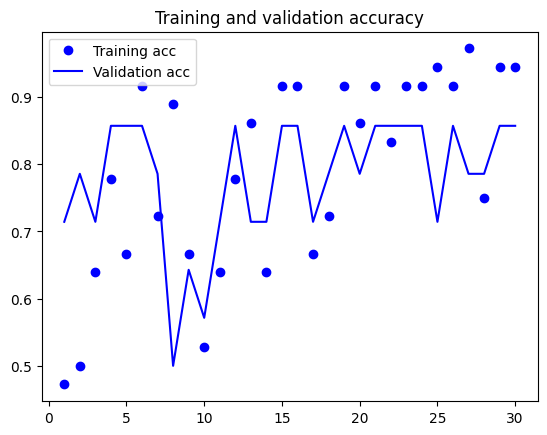

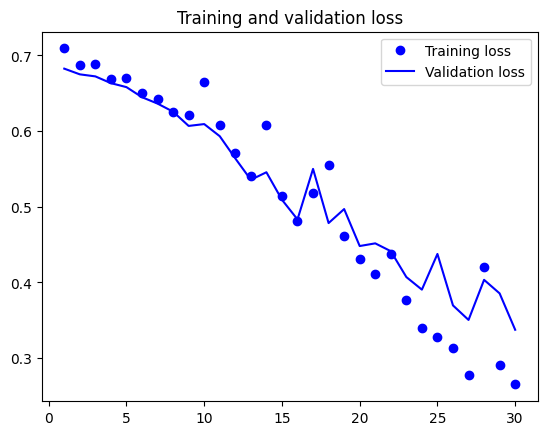

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc'), plt.plot(epochs, val_acc, 'b', label='Validation acc'), plt.title( 'Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss'), plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend ()
plt.show()

In [ ]:
datagen = ImageDataGenerator(rotation_range=40,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode='nearest')

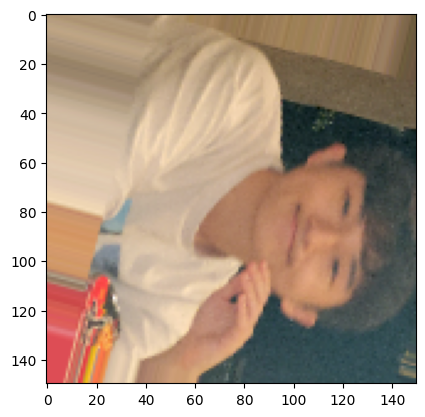

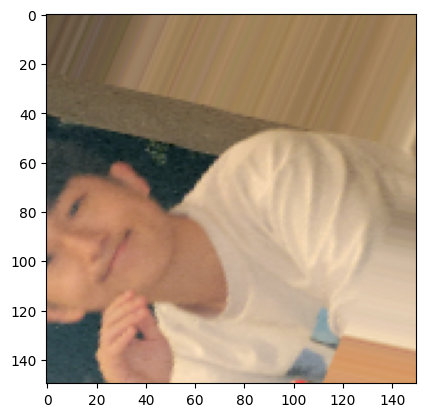

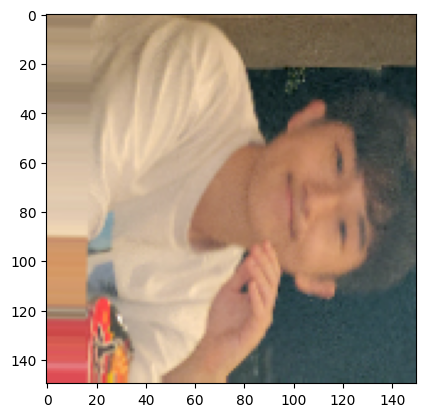

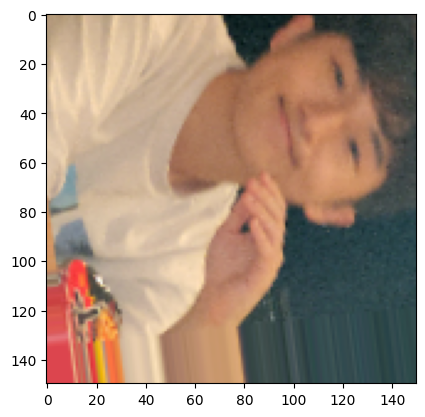

In [ ]:
import os
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from tensorflow.keras.utils import array_to_img

train_jae_dir = '/content/drive/MyDrive/assign5/train/your-name'

#get list of file names in train cats folder
fnames =[os.path.join(train_jae_dir, fname) for fname in os.listdir(train_jae_dir)]

#we pick one cat image

img_path = fnames[3]

#read the image and resize it
img = load_img(img_path, target_size=(150,150))

#convert it to a numpy array with shape (150,150,3)
x = img_to_array(img)

#reshape it to (1,150,150,3)
x=x.reshape((1,) + x.shape)

# the .flow() command below generates batches of randomly transformed images.
# it wil loop indefinitely, so we need to break the loop at some point

i=0
for batch in datagen.flow(x, batch_size=1):
  plt.figure(i)
  imgplot = plt.imshow(array_to_img(batch[0]))
  i += 1
  if i % 4 ==0:
    break

  plt.show()

In [ ]:
#dropout to see if it's extremly fitted, to avoid overfitting / pruning

model = models. Sequential()
model.add (layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add (layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add (layers.MaxPooling2D((2, 2)))
model.add (layers.Conv2D(128, (3, 3), activation='relu'))
model.add (layers.MaxPooling2D((2, 2)))
model.add (layers.Conv2D(128, (3, 3), activation='relu'))
model.add (layers.MaxPooling2D((2, 2)))
model.add (layers. Flatten())
model.add (layers. Dropout (0.5))
model.add (layers.Dense(512, activation='relu'))
model.add (layers.Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',
optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
  rescale=1./255,
  rotation_range=40,
  width_shift_range=0.2,
  height_shift_range=0.2,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True)

# Note that the validation data should not be augmented!
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
# This is the target directory
'/content/drive/MyDrive/assign5/train',
# All images will be resized to 150x150
target_size=(150, 150), batch_size=20,
# Since we use binary_crossentropy loss, we need binary labels
class_mode= 'binary')
validation_generator = test_datagen.flow_from_directory(
'/content/drive/MyDrive/assign5/validation',
target_size=(150, 150) , batch_size=20, class_mode='binary')

Found 36 images belonging to 2 classes.
Found 14 images belonging to 2 classes.


In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=50,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=50
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - acc: 0.5000 - loss: 0.6922 - val_acc: 0.5000 - val_loss: 0.6889
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - acc: 0.3611 - loss: 0.7013 - val_acc: 0.5000 - val_loss: 0.6881
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - acc: 0.4722 - loss: 0.7092 - val_acc: 0.5714 - val_loss: 0.6871
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - acc: 0.4167 - loss: 0.7001 - val_acc: 0.5000 - val_loss: 0.6819
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - acc: 0.5000 - loss: 0.6980 - val_acc: 0.5000 - val_loss: 0.6781
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - acc: 0.5000 - loss: 0.6896 - val_acc: 0.5000 - val_loss: 0.6766
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - acc: 0.5000 - loss: 0.6961 - val_acc: 0.5000 - val_loss: 0.6758
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - acc: 0.4722 - loss: 0.6873 - val_acc: 0.5000 - val_loss: 0.6748
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━

In [ ]:
model.save('assign5.h5')

In [ ]:
model.save('assign5.keras')

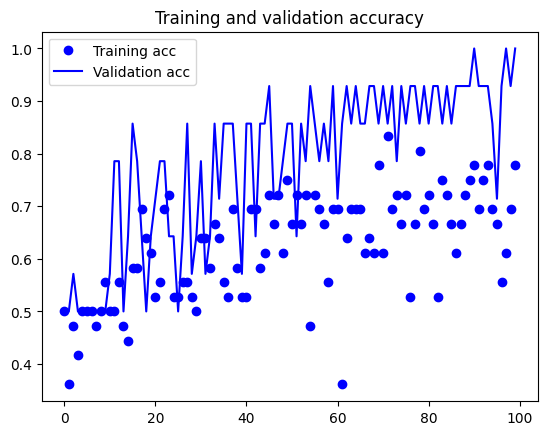

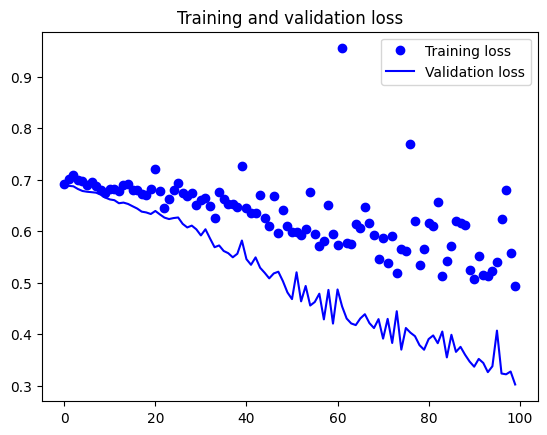

In [ ]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:
from tensorflow import keras
model = keras.models.load_model('/content/assign5.keras')


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

img = load_img('/content/your-other-image-for-prediction.jpeg', target_size=(150,150))

img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

#print prediction
if prediction[0] < 0.5:
  print("He might be a BTS member")
else:
  print("He is your-name")

#load the image that's not been used for training or validation.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
He is Jaehoon


In [ ]:
prediction = model.predict(img_array)

score = prediction[0][0]

if score < 0.5:
    confidence = (1 - score) * 100
    print(f"I am {confidence:.2f}% confident that he is a BTS member")
else:
    # If the score is 0.95, it's 95% sure it's J
    confidence = score * 100
    print(f"I am {confidence:.2f}% confident that he is your-name")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
I am 71.68% confident that he is Jaehoon
